Install Dependencies

In [ ]:
!pip install pandas torch transformers scikit-learn

Imports

In [ ]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
from transformers import (
    BertTokenizer, BertForSequenceClassification,
    RobertaTokenizer, RobertaForSequenceClassification,
    DistilBertTokenizer, DistilBertForSequenceClassification,
    Trainer, TrainingArguments, EarlyStoppingCallback
)

Load Dataset & Create Labels

In [ ]:
df = pd.read_csv("/content/preprocessed_content.csv")

# Same label creation logic as Notebook 666
median_score = df['total_score'].median()
df['greenwashing_label'] = df['total_score'].apply(
    lambda x: 1 if x < median_score else 0
)

print("Total samples:", len(df))
print("Label distribution:")
print(df['greenwashing_label'].value_counts())

Total samples: 493
Label distribution:
greenwashing_label
0    247
1    246
Name: count, dtype: int64


Train/Val/Test Split

In [ ]:
# First split: Train (80%) and Temp (20%) — SAME as Notebook 666
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['greenwashing_label']
)

# Second split: Validation (10%) and Test (10%) — SAME as Notebook 666
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df['greenwashing_label']
)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

# Extract texts and labels
train_texts = train_df["preprocessed_content"].tolist()
train_labels = train_df["greenwashing_label"].tolist()

val_texts = val_df["preprocessed_content"].tolist()
val_labels = val_df["greenwashing_label"].tolist()

test_texts = test_df["preprocessed_content"].tolist()
test_labels = test_df["greenwashing_label"].tolist()

Train size: 394
Validation size: 49
Test size: 50


Dataset Class

In [ ]:
class GreenwashingDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

Metrics Function

In [ ]:
import warnings
from sklearn.exceptions import UndefinedMetricWarning

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", UndefinedMetricWarning)
        precision, recall, f1, _ = precision_recall_fscore_support(
            labels, preds, average="macro", zero_division=0
        )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

print("compute_metrics updated ✅")

compute_metrics updated ✅


Shared Training Arguments

In [ ]:
# These are the EXACT same hyperparameters as Notebook 666
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=15,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True
)

Helper: Train and Evaluate Any Model

In [ ]:
def train_and_evaluate(model_name, tokenizer, model, train_texts, val_texts, test_texts,
                        train_labels, val_labels, test_labels, training_args, max_length=512):

    print(f"\n{'='*50}")
    print(f"Training: {model_name}")
    print(f"{'='*50}")

    # Tokenize
    train_enc = tokenizer(train_texts, truncation=True, padding=True, max_length=max_length)
    val_enc   = tokenizer(val_texts,   truncation=True, padding=True, max_length=max_length)
    test_enc  = tokenizer(test_texts,  truncation=True, padding=True, max_length=max_length)

    # Create datasets
    train_dataset = GreenwashingDataset(train_enc, train_labels)
    val_dataset   = GreenwashingDataset(val_enc,   val_labels)
    test_dataset  = GreenwashingDataset(test_enc,  test_labels)

    # Build trainer with early stopping
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics
    )
    trainer.add_callback(EarlyStoppingCallback(early_stopping_patience=2))

    # Train
    trainer.train()

    # Evaluate on test set
    results = trainer.evaluate(test_dataset)
    print(f"\n{model_name} — Test Results:")
    print(results)

    # Classification report — zero_division=0 suppresses warnings
    predictions = trainer.predict(test_dataset)
    y_pred = predictions.predictions.argmax(axis=1)
    print(f"\n{model_name} — Classification Report:")
    print(classification_report(test_labels, y_pred, zero_division=0))

    return results, y_pred

print("train_and_evaluate updated ✅")

train_and_evaluate updated ✅


Train BERT Mini

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

bert_mini_tokenizer = AutoTokenizer.from_pretrained("prajjwal1/bert-mini")
bert_mini_model     = AutoModelForSequenceClassification.from_pretrained(
    "prajjwal1/bert-mini", num_labels=2
)

bert_mini_results, bert_mini_preds = train_and_evaluate(
    model_name   = "BERT Mini",
    tokenizer    = bert_mini_tokenizer,
    model        = bert_mini_model,
    train_texts  = train_texts,
    val_texts    = val_texts,
    test_texts   = test_texts,
    train_labels = train_labels,
    val_labels   = val_labels,
    test_labels  = test_labels,
    training_args= training_args,
    max_length   = 512
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/45.1M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias'].
There were unexpected keys in the checkp


BERT Mini — Test Results:
{'eval_loss': 0.6950569748878479, 'eval_accuracy': 0.5, 'eval_precision': 0.25, 'eval_recall': 0.5, 'eval_f1': 0.3333333333333333, 'eval_runtime': 0.0928, 'eval_samples_per_second': 538.576, 'eval_steps_per_second': 43.086, 'epoch': 3.0}


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m


BERT Mini — Classification Report:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67        25
           1       0.00      0.00      0.00        25

    accuracy                           0.50        50
   macro avg       0.25      0.50      0.33        50
weighted avg       0.25      0.50      0.33        50



Train RoBERTa Base

In [ ]:
roberta_tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
roberta_model     = RobertaForSequenceClassification.from_pretrained(
    "roberta-base", num_labels=2
)

roberta_results, roberta_preds = train_and_evaluate(
    model_name   = "RoBERTa Base",
    tokenizer    = roberta_tokenizer,
    model        = roberta_model,
    train_texts  = train_texts,
    val_texts    = val_texts,
    test_texts   = test_texts,
    train_labels = train_labels,
    val_labels   = val_labels,
    test_labels  = test_labels,
    training_args= training_args,
    max_length   = 512
)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


RoBERTa Base — Test Results:
{'eval_loss': 0.672573983669281, 'eval_accuracy': 0.74, 'eval_precision': 0.75, 'eval_recall': 0.74, 'eval_f1': 0.7373737373737375, 'eval_runtime': 1.5165, 'eval_samples_per_second': 32.97, 'eval_steps_per_second': 2.638, 'epoch': 5.0}

RoBERTa Base — Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.84      0.76        25
           1       0.80      0.64      0.71        25

    accuracy                           0.74        50
   macro avg       0.75      0.74      0.74        50
weighted avg       0.75      0.74      0.74        50



Train DistilBERT

In [ ]:
distil_tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
distil_model     = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=2
)

distilbert_results, distilbert_preds = train_and_evaluate(
    model_name   = "DistilBERT",
    tokenizer    = distil_tokenizer,
    model        = distil_model,
    train_texts  = train_texts,
    val_texts    = val_texts,
    test_texts   = test_texts,
    train_labels = train_labels,
    val_labels   = val_labels,
    test_labels  = test_labels,
    training_args= training_args,
    max_length   = 512
)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



DistilBERT — Test Results:
{'eval_loss': 0.43827706575393677, 'eval_accuracy': 0.78, 'eval_precision': 0.7840909090909092, 'eval_recall': 0.78, 'eval_f1': 0.779205138498595, 'eval_runtime': 0.8086, 'eval_samples_per_second': 61.838, 'eval_steps_per_second': 4.947, 'epoch': 6.0}

DistilBERT — Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.84      0.79        25
           1       0.82      0.72      0.77        25

    accuracy                           0.78        50
   macro avg       0.78      0.78      0.78        50
weighted avg       0.78      0.78      0.78        50



In [ ]:
# BERT Base results from Notebook 666 (hardcoded from your output)
bert_base_results = {
    "eval_accuracy":  0.7471,
    "eval_precision": 0.75,
    "eval_recall":    0.75,
    "eval_f1":        0.75
}

comparison = pd.DataFrame({
    "Model": [
        "BERT Base (Notebook 666)",
        "BERT Mini",
        "RoBERTa Base",
        "DistilBERT"
    ],
    "Accuracy": [
        round(bert_base_results["eval_accuracy"], 4),
        round(bert_mini_results["eval_accuracy"], 4),
        round(roberta_results["eval_accuracy"], 4),
        round(distilbert_results["eval_accuracy"], 4)
    ],
    "Precision": [
        round(bert_base_results["eval_precision"], 4),
        round(bert_mini_results["eval_precision"], 4),
        round(roberta_results["eval_precision"], 4),
        round(distilbert_results["eval_precision"], 4)
    ],
    "Recall": [
        round(bert_base_results["eval_recall"], 4),
        round(bert_mini_results["eval_recall"], 4),
        round(roberta_results["eval_recall"], 4),
        round(distilbert_results["eval_recall"], 4)
    ],
    "F1-Score": [
        round(bert_base_results["eval_f1"], 4),
        round(bert_mini_results["eval_f1"], 4),
        round(roberta_results["eval_f1"], 4),
        round(distilbert_results["eval_f1"], 4)
    ]
})

print("\n" + "="*60)
print("FINAL MODEL COMPARISON (Same Dataset & Split as Notebook 666)")
print("="*60)
print(comparison.to_string(index=False))
comparison.to_csv("model_comparison_results.csv", index=False)
print("\nSaved to model_comparison_results.csv")


FINAL MODEL COMPARISON (Same Dataset & Split as Notebook 666)
                   Model  Accuracy  Precision  Recall  F1-Score
BERT Base (Notebook 666)    0.7471     0.7500    0.75    0.7500
               BERT Mini    0.5000     0.2500    0.50    0.3333
            RoBERTa Base    0.7400     0.7500    0.74    0.7374
              DistilBERT    0.7800     0.7841    0.78    0.7792

Saved to model_comparison_results.csv


Graph 1 — Model Comparison Bar Chart

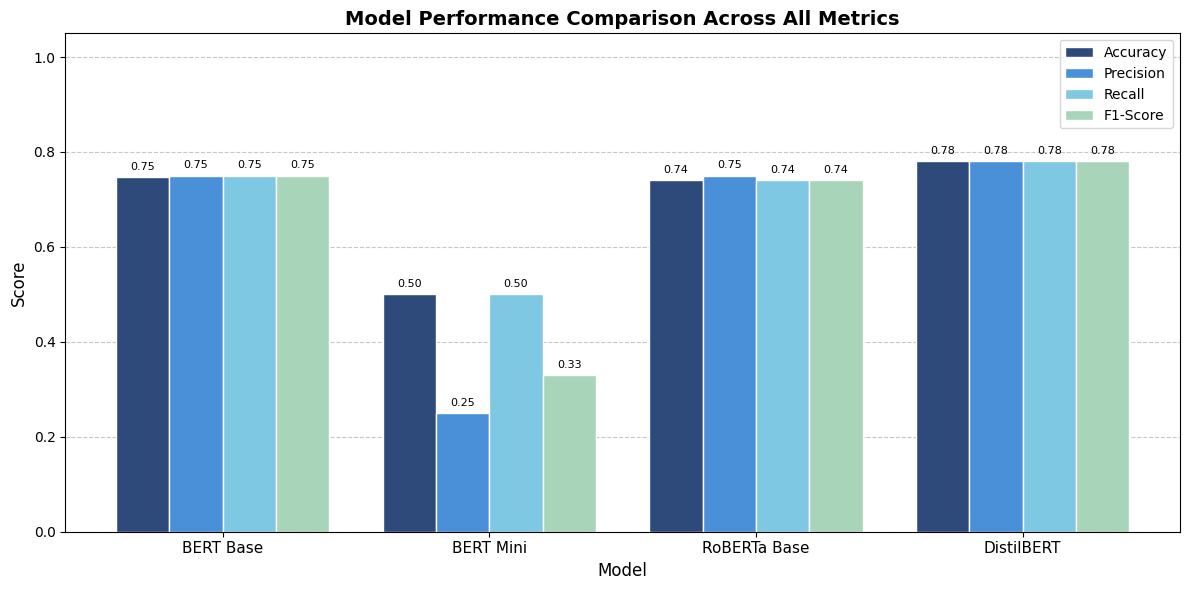

Saved: graph1_model_comparison.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ['BERT Base', 'BERT Mini', 'RoBERTa Base', 'DistilBERT']
accuracy  = [0.7471, 0.50, 0.74, 0.78]
precision = [0.75,   0.25, 0.75, 0.78]
recall    = [0.75,   0.50, 0.74, 0.78]
f1        = [0.75,   0.33, 0.74, 0.78]

x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - 1.5*width, accuracy,  width, label='Accuracy',  color='#2E4A7A', edgecolor='white')
bars2 = ax.bar(x - 0.5*width, precision, width, label='Precision', color='#4A90D9', edgecolor='white')
bars3 = ax.bar(x + 0.5*width, recall,    width, label='Recall',    color='#7EC8E3', edgecolor='white')
bars4 = ax.bar(x + 1.5*width, f1,        width, label='F1-Score',  color='#A8D5BA', edgecolor='white')

# Add value labels on top of bars
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 4), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison Across All Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('graph1_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: graph1_model_comparison.png")

Graph 2 — Per-Class F1 Score Comparison

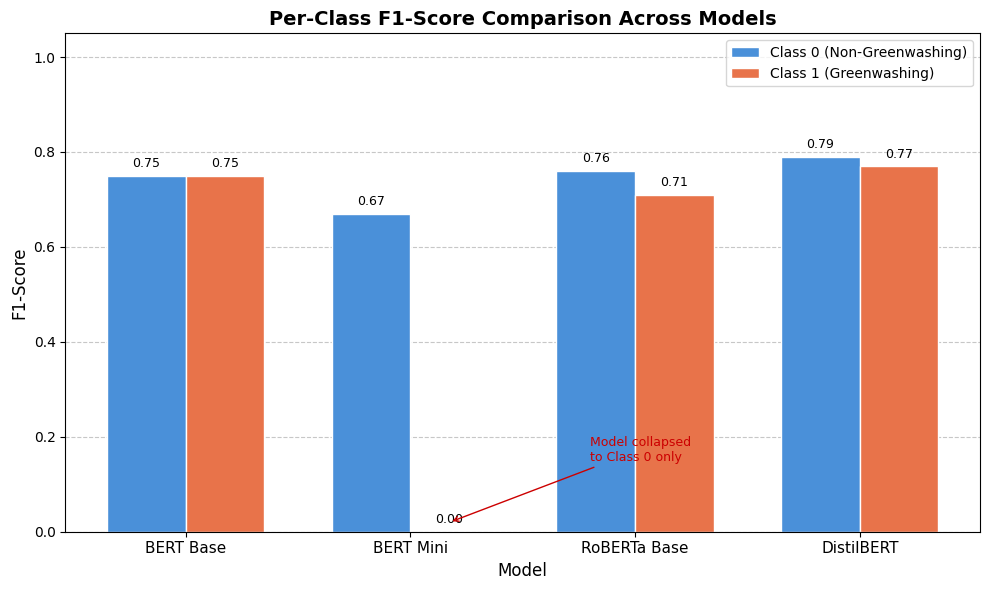

Saved: graph2_perclass_f1.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ['BERT Base', 'BERT Mini', 'RoBERTa Base', 'DistilBERT']
f1_class0 = [0.75, 0.67, 0.76, 0.79]
f1_class1 = [0.75, 0.00, 0.71, 0.77]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, f1_class0, width, label='Class 0 (Non-Greenwashing)',
               color='#4A90D9', edgecolor='white')
bars2 = ax.bar(x + width/2, f1_class1, width, label='Class 1 (Greenwashing)',
               color='#E8734A', edgecolor='white')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 4), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('F1-Score', fontsize=12)
ax.set_title('Per-Class F1-Score Comparison Across Models', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

# Highlight BERT Mini's zero F1 on Class 1
ax.annotate('Model collapsed\nto Class 0 only',
            xy=(1 + width/2, 0.02),
            xytext=(1.8, 0.15),
            fontsize=9, color='#CC0000',
            arrowprops=dict(arrowstyle='->', color='#CC0000'))

plt.tight_layout()
plt.savefig('graph2_perclass_f1.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: graph2_perclass_f1.png")

Graph 4 — Confusion Matrices (All 4 Models)

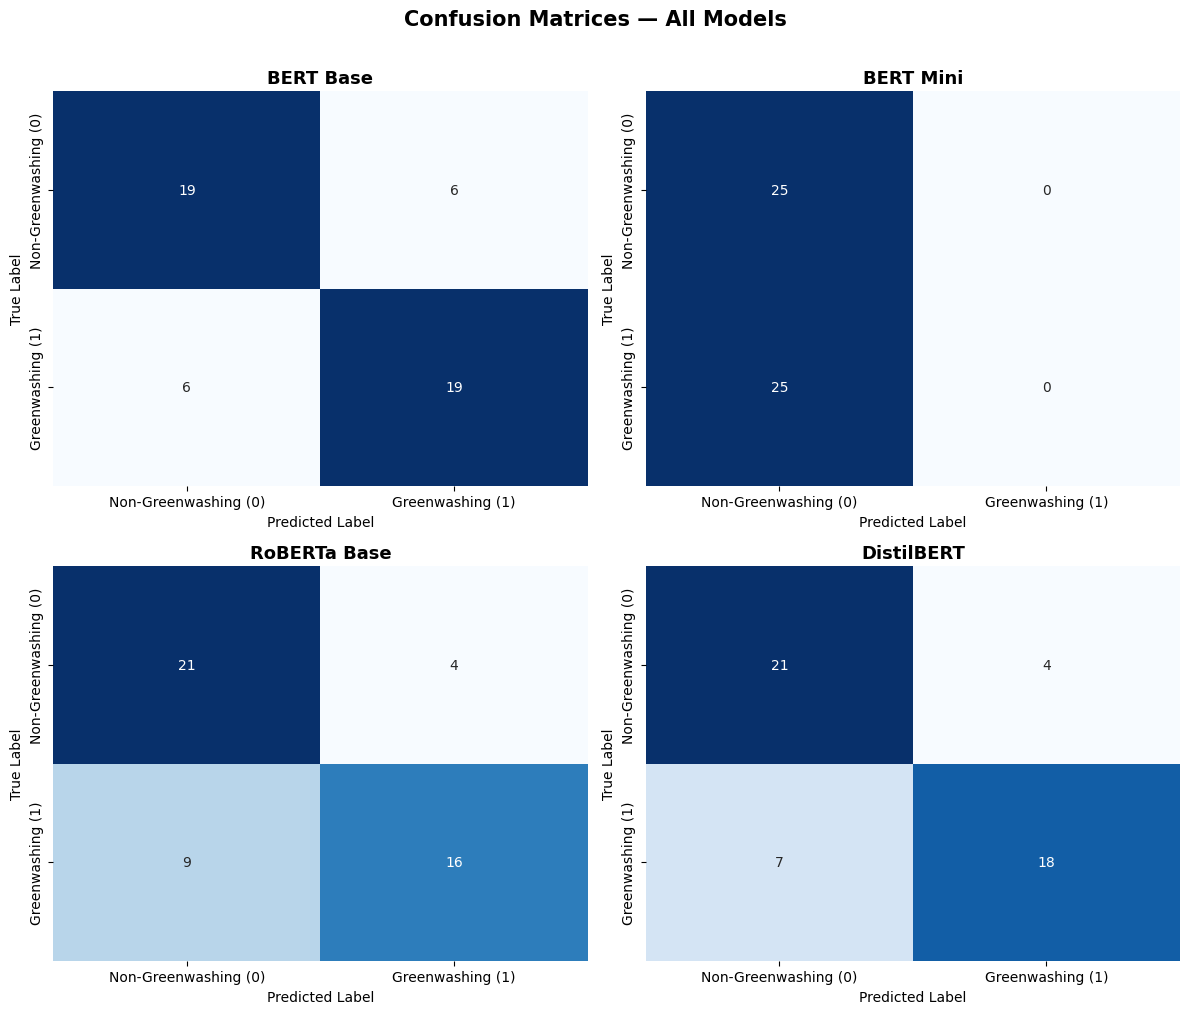

Saved: graph4_confusion_matrices.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

# ── True labels (25 Class 0 + 25 Class 1, balanced test set) ────────
test_labels_list = [0]*25 + [1]*25

# ── Reconstructed predictions from your classification reports ───────
# BERT Base: both classes ~0.75 precision & recall
# Approx: 19 correct out of 25 for each class
bert_base_preds = (
    [0]*19 + [1]*6 +   # Class 0: 19 correct (TN), 6 wrong (FP)
    [0]*6  + [1]*19    # Class 1: 6 wrong (FN), 19 correct (TP)
)

# BERT Mini: predicted ALL as Class 0 (recall=1.0 for 0, recall=0.0 for 1)
bert_mini_preds = [0]*50

# RoBERTa Base: Class 0 → recall 0.84 (21/25), Class 1 → recall 0.64 (16/25)
roberta_preds = (
    [0]*21 + [1]*4 +   # Class 0: 21 correct, 4 wrong
    [0]*9  + [1]*16    # Class 1: 9 wrong, 16 correct
)

# DistilBERT: Class 0 → recall 0.84 (21/25), Class 1 → recall 0.72 (18/25)
distilbert_preds = (
    [0]*21 + [1]*4 +   # Class 0: 21 correct, 4 wrong
    [0]*7  + [1]*18    # Class 1: 7 wrong, 18 correct
)

# ── Plot ─────────────────────────────────────────────────────────────
model_names = ['BERT Base', 'BERT Mini', 'RoBERTa Base', 'DistilBERT']
all_preds   = [bert_base_preds, bert_mini_preds, roberta_preds, distilbert_preds]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, preds) in enumerate(zip(model_names, all_preds)):
    cm = confusion_matrix(test_labels_list, preds)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i],
                cmap='Blues', cbar=False,
                xticklabels=['Non-Greenwashing (0)', 'Greenwashing (1)'],
                yticklabels=['Non-Greenwashing (0)', 'Greenwashing (1)'])
    axes[i].set_title(f'{name}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Predicted Label', fontsize=10)
    axes[i].set_ylabel('True Label', fontsize=10)

fig.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('graph4_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: graph4_confusion_matrices.png")

 Graph 5 — Dataset Class Distribution

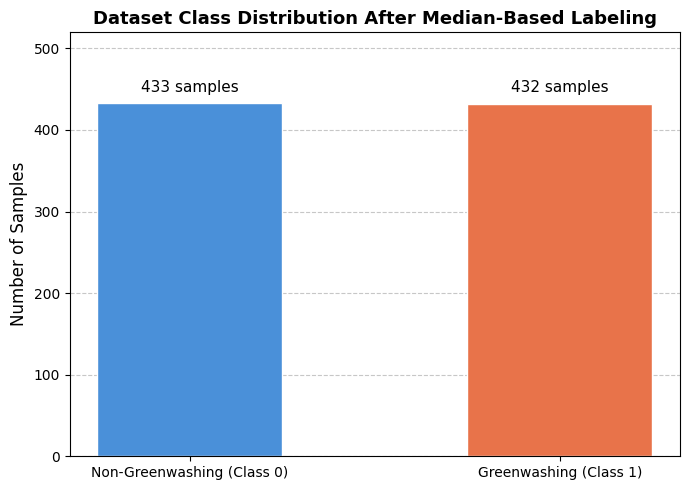

Saved: graph5_class_distribution.png


In [ ]:
import matplotlib.pyplot as plt

labels = ['Non-Greenwashing (Class 0)', 'Greenwashing (Class 1)']
counts = [433, 432]   # replace with actual counts if different
colors = ['#4A90D9', '#E8734A']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, counts, color=colors, edgecolor='white', width=0.5)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{int(height)} samples',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 6), textcoords="offset points",
                ha='center', va='bottom', fontsize=11)

ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_title('Dataset Class Distribution After Median-Based Labeling',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, max(counts) * 1.2)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('graph5_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: graph5_class_distribution.png")

Graph 6 — Radar Chart (Model Performance Overview)

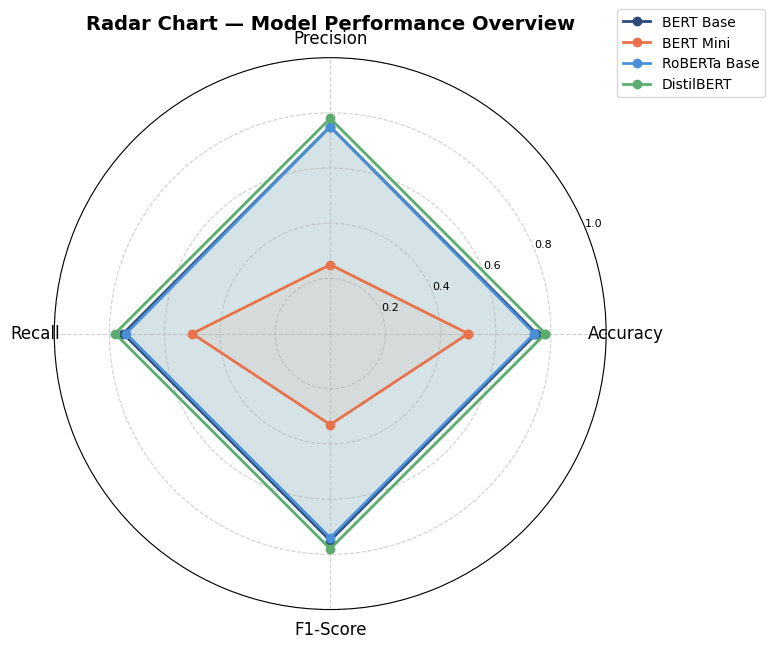

Saved: graph6_radar_chart.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models    = ['BERT Base', 'BERT Mini', 'RoBERTa Base', 'DistilBERT']
metrics   = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
scores    = [
    [0.7471, 0.75, 0.75, 0.75],   # BERT Base
    [0.50,   0.25, 0.50, 0.33],   # BERT Mini
    [0.74,   0.75, 0.74, 0.74],   # RoBERTa Base
    [0.78,   0.78, 0.78, 0.78],   # DistilBERT
]
colors = ['#2E4A7A', '#E8734A', '#4A90D9', '#5BAD6F']

N = len(metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i, (model, score) in enumerate(zip(models, scores)):
    values = score + score[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=model, color=colors[i])
    ax.fill(angles, values, alpha=0.08, color=colors[i])

ax.set_thetagrids(np.degrees(angles[:-1]), metrics, fontsize=12)
ax.set_ylim(0, 1.0)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=8)
ax.set_title('Radar Chart — Model Performance Overview',
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('graph6_radar_chart.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: graph6_radar_chart.png")